<a href="https://colab.research.google.com/github/manasamorthad/DeepLearning/blob/main/week_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3385 - val_loss: 0.2716
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2678 - val_loss: 0.2654
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2648 - val_loss: 0.2640
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2639 - val_loss: 0.2636
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2635 - val_loss: 0.2631
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2633 - val_loss: 0.2630
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2628 - val_loss: 0.2612
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2570 - val_loss: 0.2520
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2477 - val_loss: 0.2423
E

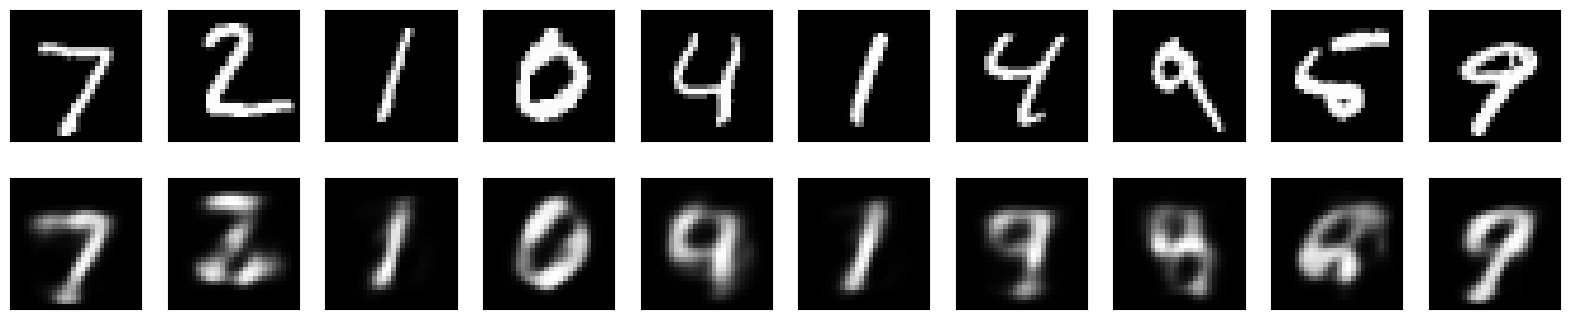

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2734 - val_loss: 0.1882
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1703 - val_loss: 0.1540
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1446 - val_loss: 0.1341
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1285 - val_loss: 0.1211
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1177 - val_loss: 0.1123
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1104 - val_loss: 0.1063
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1054 - val_loss: 0.1021
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1018 - val_loss: 0.0992
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0994 - val_loss: 0.0973
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0978 - val_loss: 0.0959
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0968 - val_loss: 0.0950
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

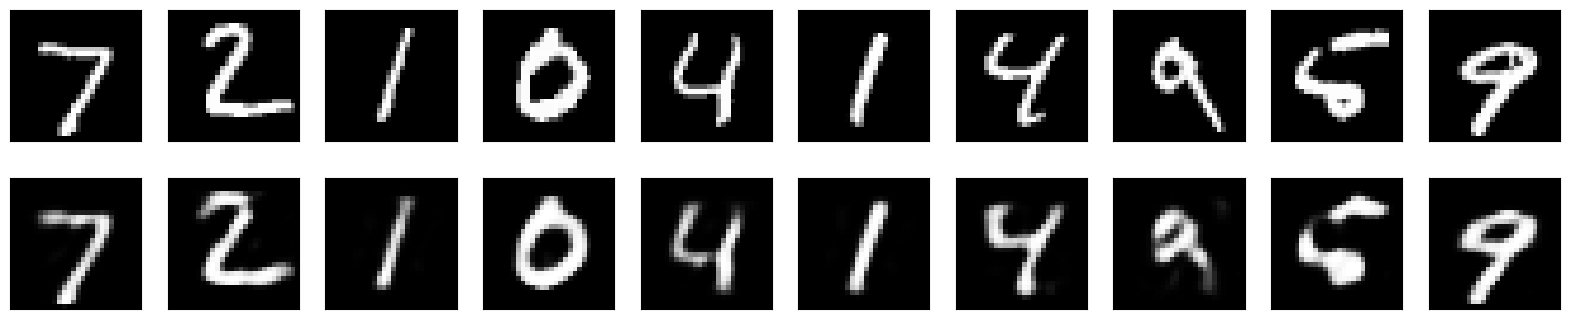

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2436 - val_loss: 0.1620
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1430 - val_loss: 0.1250
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1171 - val_loss: 0.1079
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1035 - val_loss: 0.0974
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0947 - val_loss: 0.0903
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0886 - val_loss: 0.0853
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0843 - val_loss: 0.0818
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0813 - val_loss: 0.0792
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0792 - val_loss: 0.0776
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0777 - val_loss: 0.0764
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0767 - val_loss: 0.0756
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

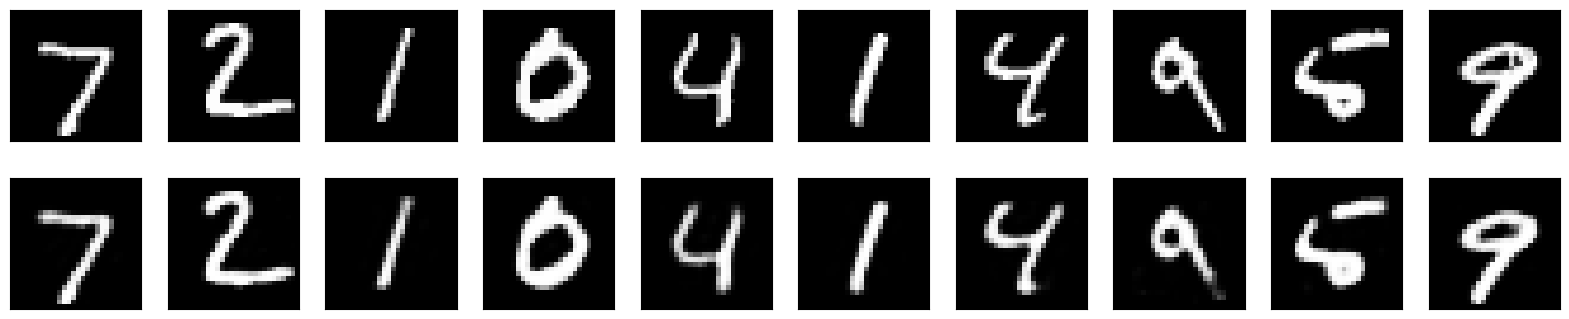

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 64  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.1223 - val_loss: 0.0808
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0780 - val_loss: 0.0746
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0742 - val_loss: 0.0724
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0724 - val_loss: 0.0712
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0713 - val_loss: 0.0710
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0705 - val_loss: 0.0695
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0699 - val_loss: 0.0690
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0694 - val_loss: 0.0686
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0690 - val_loss: 0.0683
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0686 - val_loss: 0.0681
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0683 - val_loss: 0.0677
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/st

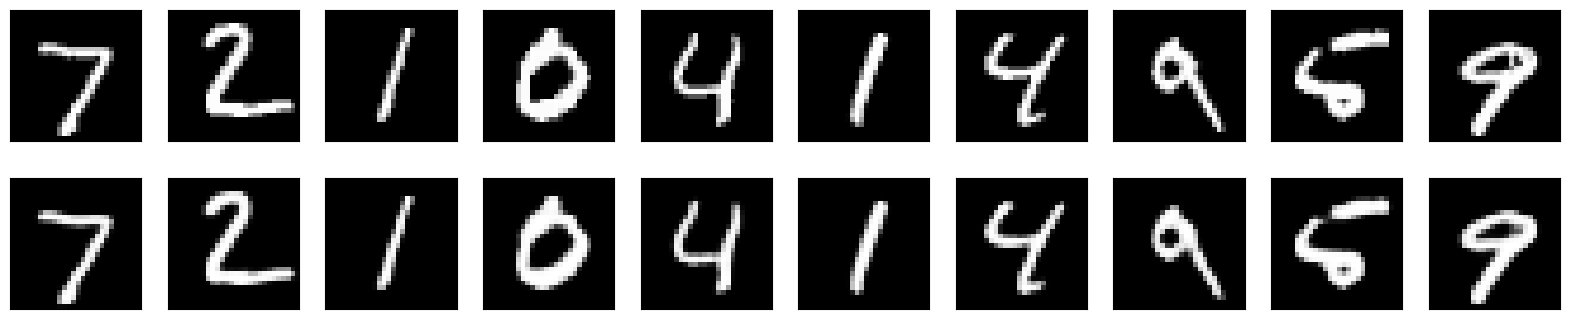

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import TensorBoard

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape for CNN: (samples, height, width, channels)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# 2. Define the Encoder and Decoder
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# 3. Create the Autoencoder Model
autoencoder = Model(input_img, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
tensorboard = TensorBoard(log_dir='./logs', histogram_freq=1)

autoencoder.fit(
    x_train, x_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[tensorboard]
)

# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test)

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.6366 - val_loss: 0.6180
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6139 - val_loss: 0.6053
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6066 - val_loss: 0.6004
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6029 - val_loss: 0.5970
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5993 - val_loss: 0.5943
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5979 - val_loss: 0.5932
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5965 - val_loss: 0.5928
Epoch 8/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5965 - val_loss: 0.5920
Epoch 9/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5949 - val_loss: 0.5914
Epoch 10/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5942 - val_loss: 0.5908
Epoch 11/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5939 - val_loss: 0.5903
Epoch 12/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

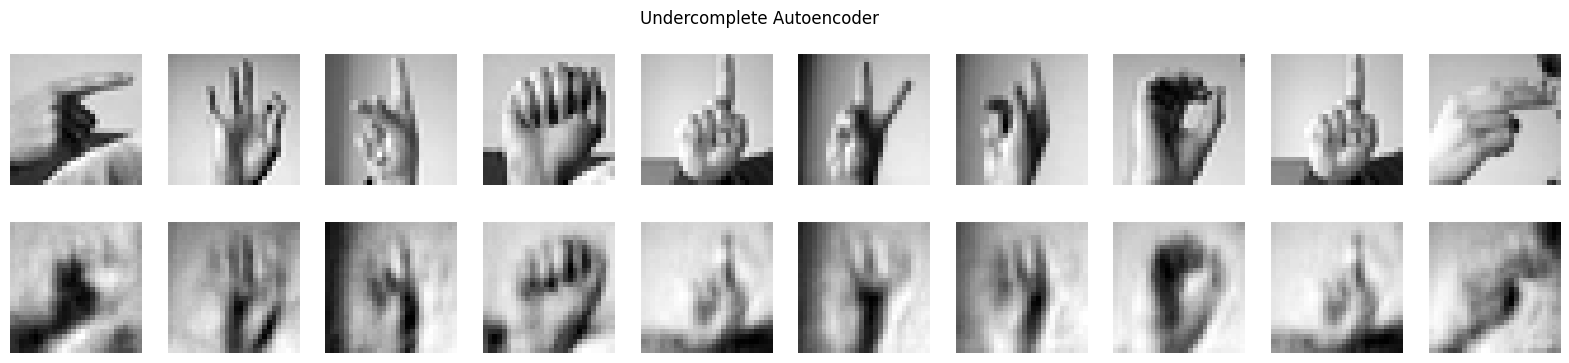

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# 4. Input dimension
input_dim = x_train.shape[1]   # 784
encoding_dim = 128             # undercomplete (< 784)

input_layer = Input(shape=(input_dim,))
hidden1 = Dense(256, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(hidden1)

hidden2 = Dense(256, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(hidden2)

undercomplete_ae = Model(input_layer, decoded)

# 6. Compile
undercomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')

# 7. Train
history_under = undercomplete_ae.fit(
    x_train, x_train,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 8. Predict
decoded_imgs_under = undercomplete_ae.predict(x_test)

# 9. Visualize
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_under[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Undercomplete Autoencoder")
plt.show()

Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.6182 - val_loss: 0.6001
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5993 - val_loss: 0.5946
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5956 - val_loss: 0.5912
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5938 - val_loss: 0.5899
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5925 - val_loss: 0.5891
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5916 - val_loss: 0.5888
Epoch 7/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5908 - val_loss: 0.5877
Epoch 8/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5902 - val_loss: 0.5874
Epoch 9/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5897 - val_loss: 0.5868
Epoch 10/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5893 - val_loss: 0.5868
Epoch 11/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5889 - val_loss: 0.5864
Epoch 12/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

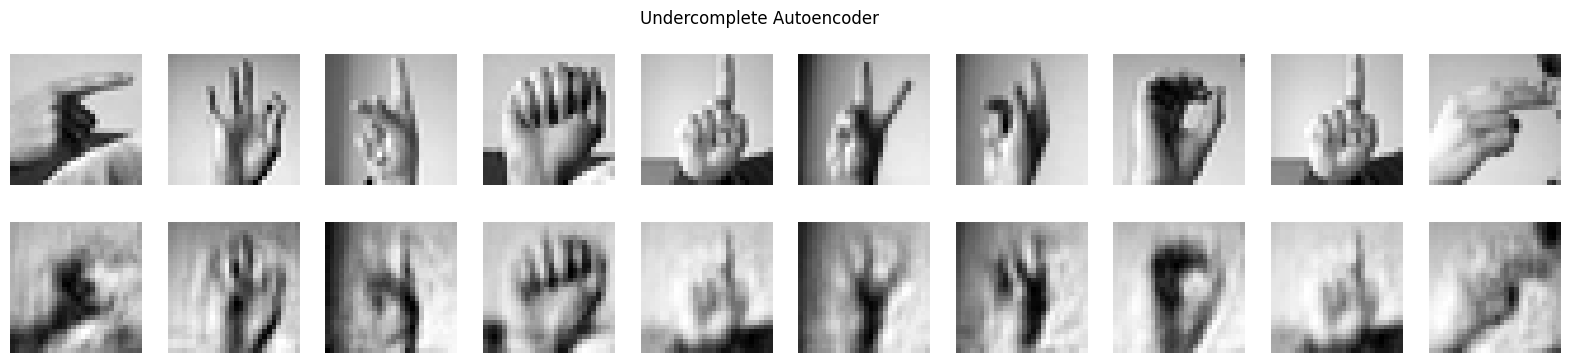

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# 4. Input dimension
input_dim = x_train.shape[1]   # 784
encoding_dim = 128             # undercomplete (< 784)

input_layer = Input(shape=(input_dim,))
hidden1 = Dense(256, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(hidden1)

hidden2 = Dense(256, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(hidden2)

undercomplete_ae = Model(input_layer, decoded)

# 6. Compile
undercomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')

# 7. Train
history_under = undercomplete_ae.fit(
    x_train, x_train,
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 8. Predict
decoded_imgs_under = undercomplete_ae.predict(x_test)

# 9. Visualize
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_under[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Undercomplete Autoencoder")
plt.show()

Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0170 - val_loss: 0.0111
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0086 - val_loss: 0.0077
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0070 - val_loss: 0.0070
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0062 - val_loss: 0.0062
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0056 - val_loss: 0.0062
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0052 - val_loss: 0.0059
Epoch 7/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0049 - val_loss: 0.0053
Epoch 8/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0052
Epoch 9/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - val_loss: 0.0051
Epoch 10/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - val_loss: 0.0051
Epoch 11/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0041 - val_loss: 0.0047
Epoch 12/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

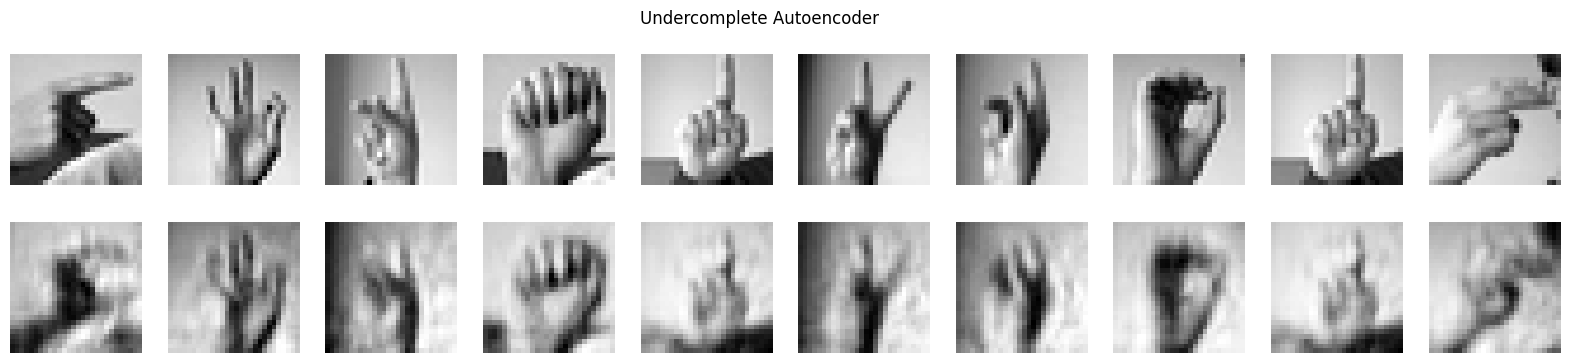

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# 4. Input dimension
input_dim = x_train.shape[1]   # 784
encoding_dim = 128             # undercomplete (< 784)

input_layer = Input(shape=(input_dim,))
hidden1 = Dense(256, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(hidden1)

hidden2 = Dense(256, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(hidden2)

undercomplete_ae = Model(input_layer, decoded)

# 6. Compile
undercomplete_ae.compile(optimizer='adam', loss='mse')

# 7. Train
history_under = undercomplete_ae.fit(
    x_train, x_train,
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 8. Predict
decoded_imgs_under = undercomplete_ae.predict(x_test)

# 9. Visualize
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_under[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Undercomplete Autoencoder")
plt.show()

Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.5966 - val_loss: 0.5837
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5869 - val_loss: 0.5817
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5851 - val_loss: 0.5802
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5841 - val_loss: 0.5794
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5833 - val_loss: 0.5789
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5829 - val_loss: 0.5786
Epoch 7/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5825 - val_loss: 0.5782
Epoch 8/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5822 - val_loss: 0.5780
Epoch 9/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5821 - val_loss: 0.5778
Epoch 10/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5818 - val_loss: 0.5776
Epoch 11/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5817 - val_loss: 0.5775
Epoch 12/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/st

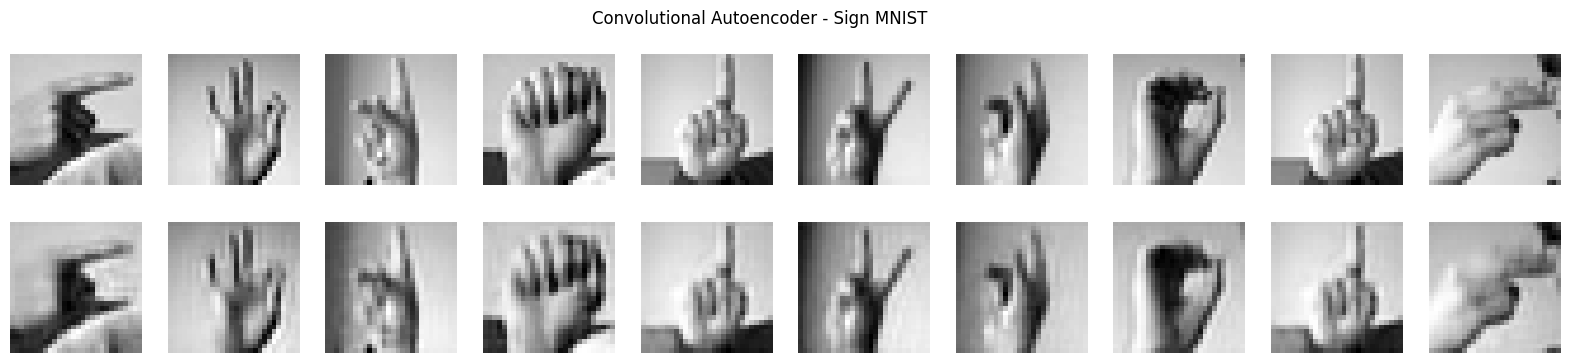

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# 4. Reshape for CNN
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# 5. Build Convolutional Autoencoder
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# 6. Create model
autoencoder = Model(input_img, decoded)

# 7. Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 8. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 9. Train
history = autoencoder.fit(
    x_train, x_train,
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop]
)

# 10. Predict
decoded_imgs = autoencoder.predict(x_test)

# 11. Visualize original vs reconstructed
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Convolutional Autoencoder - Sign MNIST")
plt.show()

Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.6130 - val_loss: 0.5976
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5978 - val_loss: 0.5905
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5922 - val_loss: 0.5874
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5895 - val_loss: 0.5856
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5878 - val_loss: 0.5846
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5866 - val_loss: 0.5847
Epoch 7/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5860 - val_loss: 0.5830
Epoch 8/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5855 - val_loss: 0.5820
Epoch 9/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5851 - val_loss: 0.5816
Epoch 10/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5847 - val_loss: 0.5813
Epoch 11/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5844 - val_loss: 0.5815
Epoch 12/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

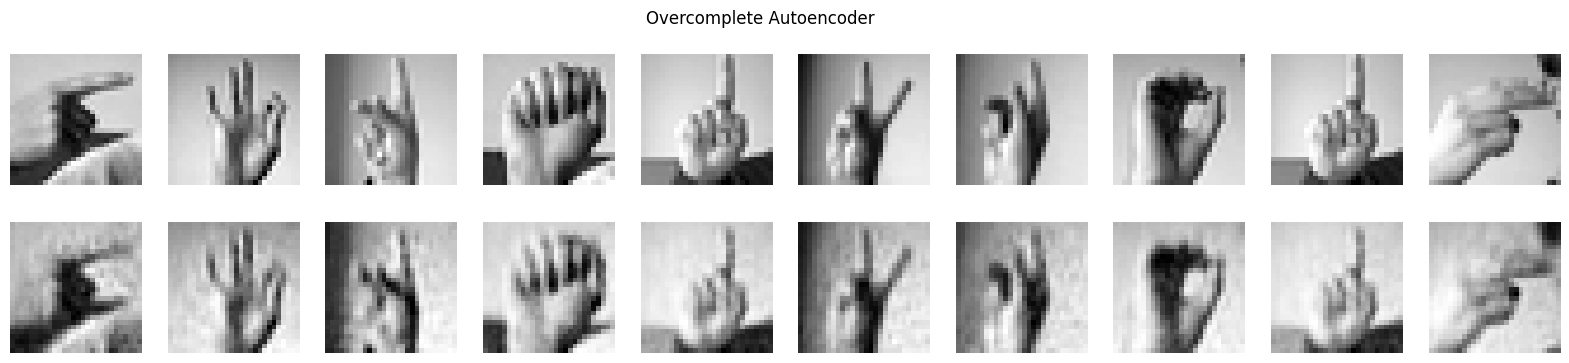

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# 4. Input dimension
input_dim = x_train.shape[1]   # 784
encoding_dim = 1024            # overcomplete (> 784)

# 5. Build Overcomplete AE
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

overcomplete_ae = Model(input_layer, decoded)

# 6. Compile
overcomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')

# 7. Train
history_over = overcomplete_ae.fit(
    x_train, x_train,
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 8. Predict
decoded_imgs_over = overcomplete_ae.predict(x_test)

# 9. Visualize
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_over[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Overcomplete Autoencoder")
plt.show()

Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.6136 - val_loss: 0.5962
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5962 - val_loss: 0.5910
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5926 - val_loss: 0.5885
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5906 - val_loss: 0.5875
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5890 - val_loss: 0.5862
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5880 - val_loss: 0.5854
Epoch 7/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5871 - val_loss: 0.5853
Epoch 8/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5866 - val_loss: 0.5842
Epoch 9/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5859 - val_loss: 0.5838
Epoch 10/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5856 - val_loss: 0.5836
Epoch 11/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5851 - val_loss: 0.5836
Epoch 12/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

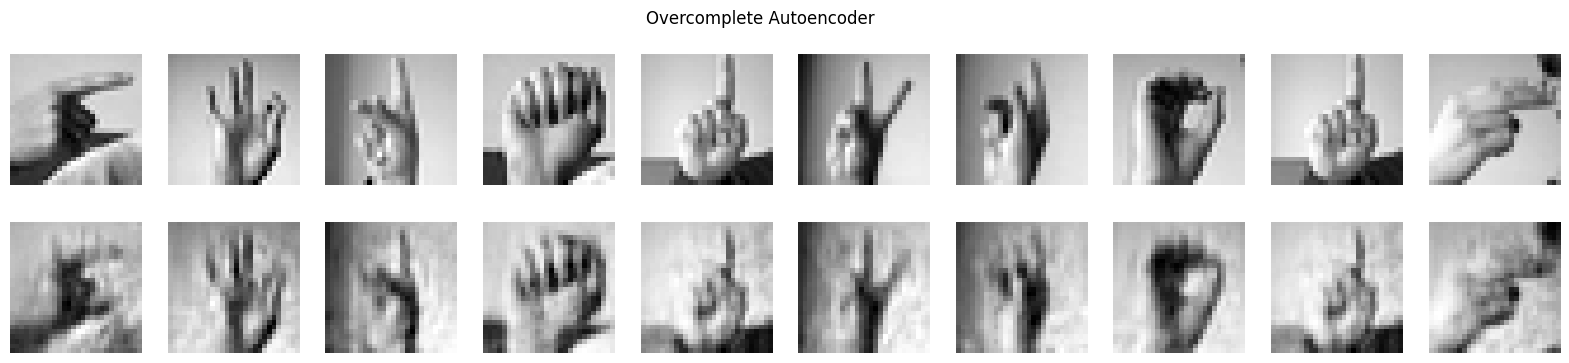

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# 4. Input dimension
input_dim = x_train.shape[1]   # 784
encoding_dim = 1024            # overcomplete (> 784)

# 5. Build Overcomplete AE
input_layer = Input(shape=(input_dim,))
hidden1 = Dense(512, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(hidden1)

hidden2 = Dense(512, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(hidden2)

overcomplete_ae = Model(input_layer, decoded)

# 6. Compile
overcomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')

# 7. Train
history_over = overcomplete_ae.fit(
    x_train, x_train,
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 8. Predict
decoded_imgs_over = overcomplete_ae.predict(x_test)

# 9. Visualize
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_over[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Overcomplete Autoencoder")
plt.show()

**Implement Regularization in AE and demonstrate its use.**


Epoch 1/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6436 - val_loss: 0.6229
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6186 - val_loss: 0.6089
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6083 - val_loss: 0.6016
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6034 - val_loss: 0.5985
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6007 - val_loss: 0.5961
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5988 - val_loss: 0.5945
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5976 - val_loss: 0.5933
Epoch 8/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5966 - val_loss: 0.5924
Epoch 9/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5955 - val_loss: 0.5920
Epoch 10/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5948 - val_loss: 0.5912
Epoch 11/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5941 - val_loss: 0.5905
Epoch 12/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

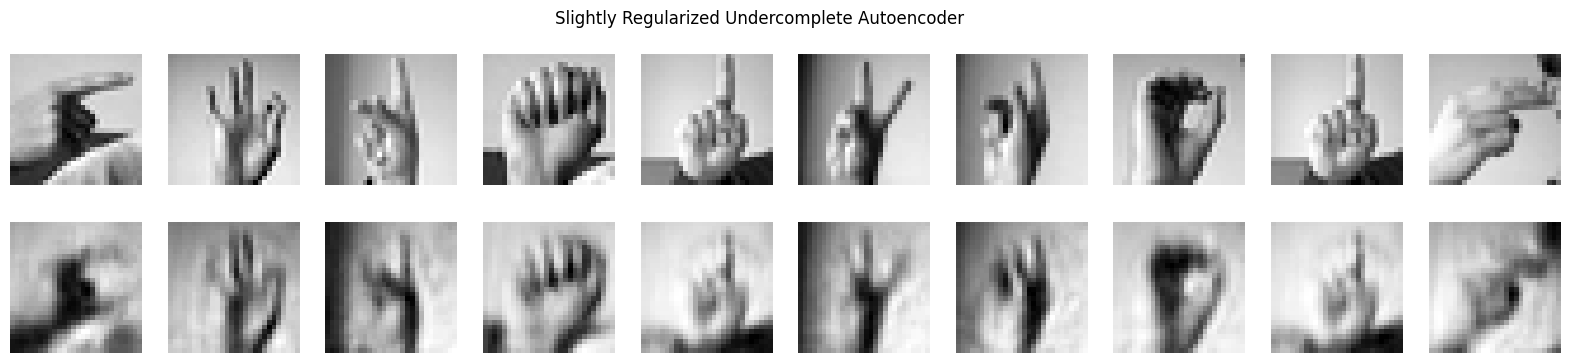

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize pixel values
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# 4. Input dimension
input_dim = x_train.shape[1]   # 784
encoding_dim = 128             # undercomplete (< 784)

# 5. Slightly improved Undercomplete AE
input_layer = Input(shape=(input_dim,))

encoded = Dense(
    encoding_dim,
    activation='sigmoid',
    kernel_regularizer=regularizers.l2(1e-7)
)(input_layer)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

undercomplete_ae = Model(input_layer, decoded)

# 6. Compile
undercomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')

# 7. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 8. Train
history_under = undercomplete_ae.fit(
    x_train, x_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop]
)

# 9. Predict
decoded_imgs_under = undercomplete_ae.predict(x_test)

# 10. Visualize
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_under[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Slightly Regularized Undercomplete Autoencoder")
plt.show()

Training Regularized Convolutional Autoencoder...
Epoch 1/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.6030 - val_loss: 0.5868
Epoch 2/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5904 - val_loss: 0.5844
Epoch 3/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5888 - val_loss: 0.5833
Epoch 4/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5880 - val_loss: 0.5825
Epoch 5/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5874 - val_loss: 0.5821
Epoch 6/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5869 - val_loss: 0.5819
Epoch 7/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5866 - val_loss: 0.5813
Epoch 8/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5863 - val_loss: 0.5810
Epoch 9/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5860 - val_loss: 0.5811
Epoch 10/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5858 - val_loss: 0.5804
Epoch 11/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5856 - val_loss: 0.5807


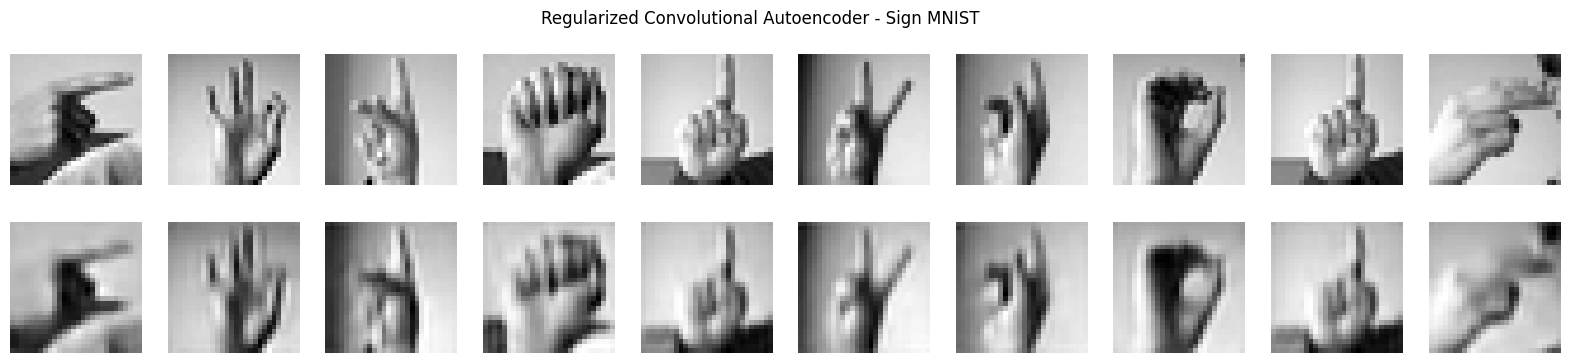

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 4. Reshape to 28x28x1
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# 5. Build Regularized Convolutional Autoencoder
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(
    32, (3, 3),
    activation='relu',
    padding='same',
    kernel_regularizer=regularizers.l2(1e-5)
)(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Dropout(0.1)(x)

x = layers.Conv2D(
    16, (3, 3),
    activation='relu',
    padding='same',
    kernel_regularizer=regularizers.l2(1e-5)
)(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(
    16, (3, 3),
    activation='relu',
    padding='same',
    kernel_regularizer=regularizers.l2(1e-5)
)(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(
    32, (3, 3),
    activation='relu',
    padding='same',
    kernel_regularizer=regularizers.l2(1e-5)
)(x)
x = layers.Dropout(0.1)(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# 6. Model
conv_ae = models.Model(input_img, decoded)

# 7. Compile
conv_ae.compile(optimizer='adam', loss='binary_crossentropy')

# 8. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 9. Train
print("Training Regularized Convolutional Autoencoder...")
history = conv_ae.fit(
    x_train, x_train,
    epochs=50,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop]
)

# 10. Predict
decoded_imgs = conv_ae.predict(x_test)

# 11. Visualize results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Regularized Convolutional Autoencoder - Sign MNIST")
plt.show()

Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.6096 - val_loss: 0.5977
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6001 - val_loss: 0.5946
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5987 - val_loss: 0.5938
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5979 - val_loss: 0.5935
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5974 - val_loss: 0.5928
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5971 - val_loss: 0.5924
Epoch 7/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5968 - val_loss: 0.5923
Epoch 8/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5967 - val_loss: 0.5921
Epoch 9/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5965 - val_loss: 0.5921
Epoch 10/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5963 - val_loss: 0.5919
Epoch 11/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5962 - val_loss: 0.5919
Epoch 12/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/ste

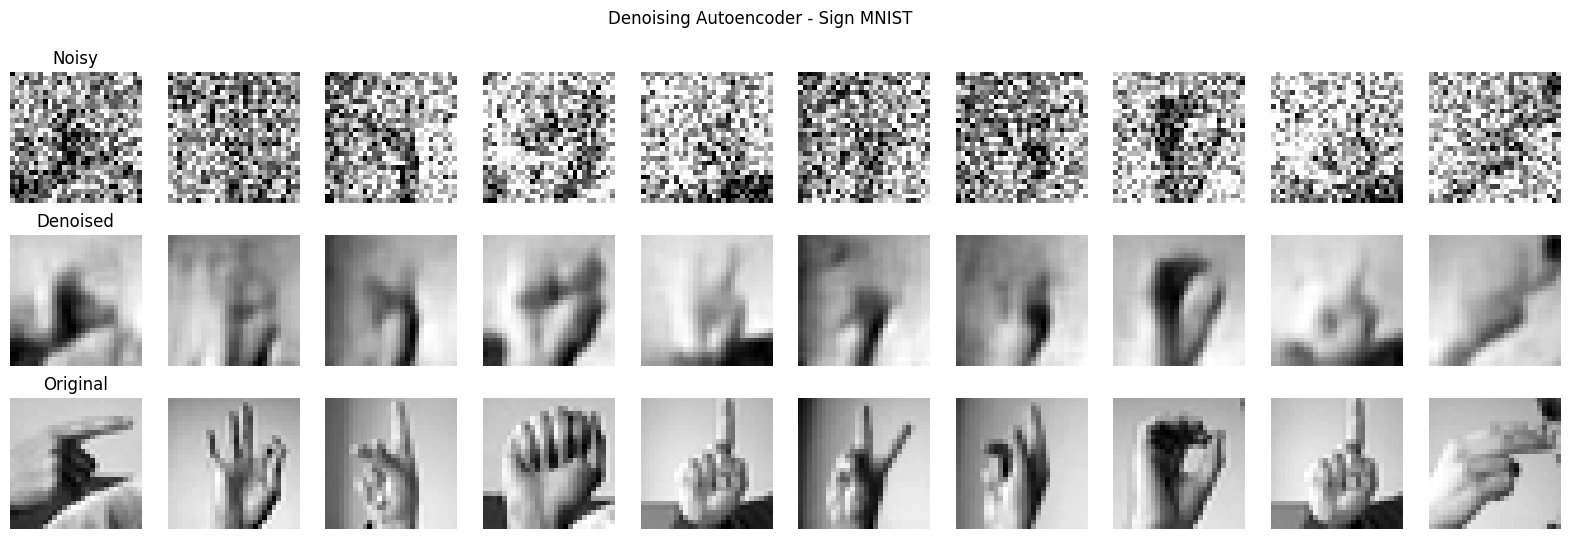

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values
x_test = test.iloc[:, 1:].values

# 3. Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 4. Reshape to 28x28x1
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# 5. Add noise
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to keep pixels in valid range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 6. Build denoising autoencoder
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

dae = models.Model(input_img, decoded)

# 7. Compile
dae.compile(optimizer='adam', loss='binary_crossentropy')

# 8. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 9. Train
history = dae.fit(
    x_train_noisy, x_train,   # noisy input, clean target
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

# 10. Predict denoised output
decoded_imgs = dae.predict(x_test_noisy)

# 11. Visualize noisy vs reconstructed vs original
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Noisy input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("Noisy")

    # Reconstructed output
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("Denoised")

    # Original clean image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("Original")

plt.suptitle("Denoising Autoencoder - Sign MNIST")
plt.show()

Epoch 1/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.6020 - val_loss: 0.5898
Epoch 2/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5933 - val_loss: 0.5884
Epoch 3/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5922 - val_loss: 0.5875
Epoch 4/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5915 - val_loss: 0.5871
Epoch 5/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5911 - val_loss: 0.5867
Epoch 6/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5908 - val_loss: 0.5865
Epoch 7/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5906 - val_loss: 0.5870
Epoch 8/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5904 - val_loss: 0.5861
Epoch 9/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5901 - val_loss: 0.5859
Epoch 10/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5900 - val_loss: 0.5860
Epoch 11/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5899 - val_loss: 0.5856
Epoch 12/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/st

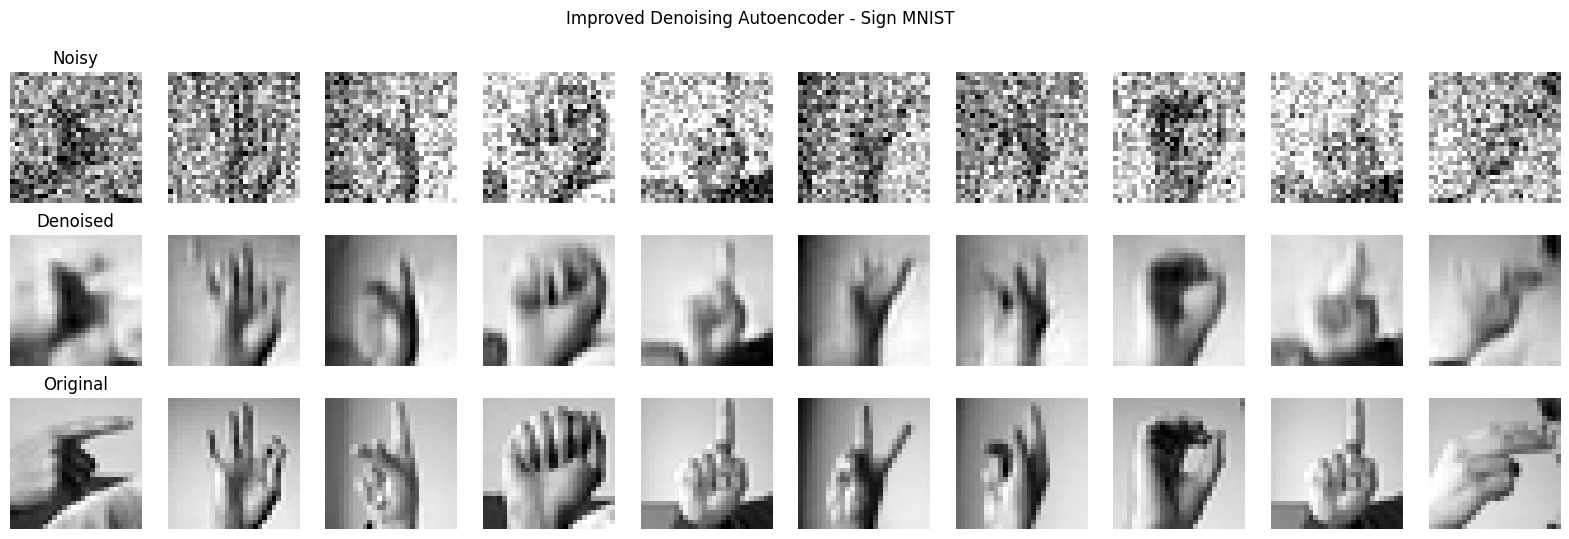

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
x_train = train.iloc[:, 1:].values.astype("float32") / 255.0
x_test = test.iloc[:, 1:].values.astype("float32") / 255.0

# 3. Reshape
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# 4. Add noise
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 5. Build improved denoising autoencoder
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

dae = models.Model(input_img, decoded)

# 6. Compile
dae.compile(optimizer='adam', loss='binary_crossentropy')

# 7. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 8. Train
history = dae.fit(
    x_train_noisy, x_train,
    epochs=50,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

# 9. Predict
decoded_imgs = dae.predict(x_test_noisy)

# 10. Visualize
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("Noisy")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("Denoised")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("Original")

plt.suptitle("Improved Denoising Autoencoder - Sign MNIST")
plt.show()

Applying PCA...
PCA Reconstruction MSE: 0.0034113614819943905
PCA Explained Variance Ratio (sum): 0.9086015
Training Autoencoder...
Epoch 1/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.6309 - val_loss: 0.6130
Epoch 2/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6125 - val_loss: 0.6045
Epoch 3/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6059 - val_loss: 0.5997
Epoch 4/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6017 - val_loss: 0.5961
Epoch 5/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5990 - val_loss: 0.5952
Epoch 6/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5975 - val_loss: 0.5932
Epoch 7/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5967 - val_loss: 0.5927
Epoch 8/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5963 - val_loss: 0.5923
Epoch 9/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5960 - val_loss: 0.5922
Epoch 10/50
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5960 - val_loss: 0.5926
Epoch 1

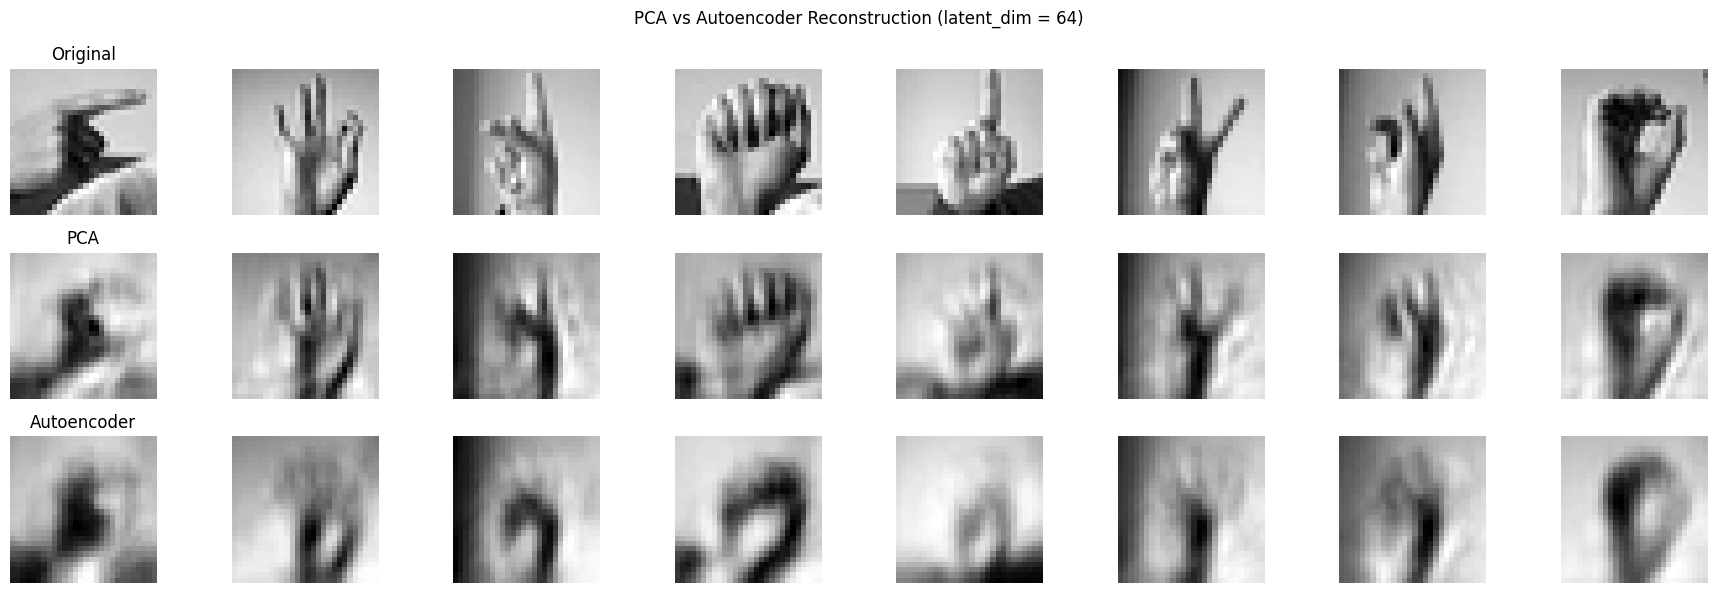

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# 2. Separate labels and images
y_train = train.iloc[:, 0].values
y_test = test.iloc[:, 0].values

x_train = train.iloc[:, 1:].values.astype("float32") / 255.0
x_test = test.iloc[:, 1:].values.astype("float32") / 255.0

# 3. Set reduced dimension
latent_dim = 64

# -------------------------------
# PCA
# -------------------------------
print("Applying PCA...")
pca = PCA(n_components=latent_dim)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

# Reconstruct from PCA
x_test_pca_reconstructed = pca.inverse_transform(x_test_pca)

# PCA reconstruction error
pca_mse = mean_squared_error(x_test, x_test_pca_reconstructed)
print("PCA Reconstruction MSE:", pca_mse)

# Explained variance
print("PCA Explained Variance Ratio (sum):", np.sum(pca.explained_variance_ratio_))

# -------------------------------
# Autoencoder
# -------------------------------
print("Training Autoencoder...")
input_dim = x_train.shape[1]   # 784

input_layer = Input(shape=(input_dim,))
encoded = Dense(latent_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

# Decoder model separately
encoded_input = Input(shape=(latent_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[early_stop],
    verbose=1
)

# AE compressed and reconstructed data
x_test_ae_encoded = encoder.predict(x_test)
x_test_ae_reconstructed = autoencoder.predict(x_test)

# AE reconstruction error
ae_mse = mean_squared_error(x_test, x_test_ae_reconstructed)
print("Autoencoder Reconstruction MSE:", ae_mse)

# -------------------------------
# Visual comparison
# -------------------------------
n = 8
plt.figure(figsize=(18, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("Original")

    # PCA reconstructed
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_pca_reconstructed[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("PCA")

    # AE reconstructed
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test_ae_reconstructed[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.set_title("Autoencoder")

plt.suptitle(f"PCA vs Autoencoder Reconstruction (latent_dim = {latent_dim})")
plt.tight_layout()
plt.show()